In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install pennylane-lightning[gpu]

In [ ]:
pip install imbalanced-learn

In [ ]:
!pip install pennylane #numpy pandas scikit-learn

## Binary Classification based on KDD99 dataset

## Reading the Dataset

In [15]:
import pandas as pd
# Load the data
file_path = '/content/drive/MyDrive/phd3/NSLKDD_Code/KDDTrain+_20Percent.txt'
df = pd.read_csv(file_path)

## Add columns names

In [16]:
# Define the list of column names based on the NSL-KDD dataset description
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack', 'level'
]

In [17]:
# Assign the column names to the dataframe
df.columns = columns

In [18]:
rows, cols = df.shape

print('New dimension:')
print(f'Number of rows: {rows}')
print(f'Number of columns: {cols}')
print(f'Total cells: {rows * cols}')

New dimension:
Number of rows: 25191
Number of columns: 43
Total cells: 1083213


In [7]:
print("First 5 rows of the dataset after assigning columns names :")
display(df.head())

First 5 rows of the dataset after assigning columns names :


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [19]:
# Convert the attack column to binary labels: 'normal' or 'attack'
df['attack'] = df['attack'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

In [20]:
df['attack'].unique()

array(['normal', 'attack'], dtype=object)

## Attack Counts over Protocol Types

In [22]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

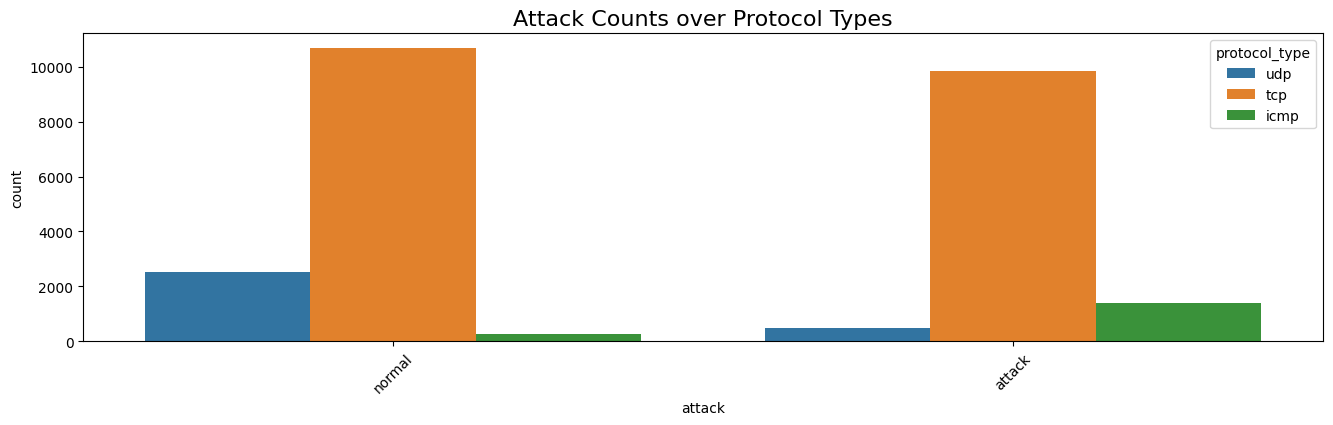

In [ ]:
# Set figure size
plt.figure(figsize=(16, 4))

# Create a count plot of attack types grouped by protocol type
sns.countplot(x='attack', data=df, hue='protocol_type')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Set plot title
plt.title('Attack Counts over Protocol Types', fontdict={'fontsize': 16})

# Show the plot
plt.show()


Class distribution:
attack
normal    13448
attack    11743
Name: count, dtype: int64


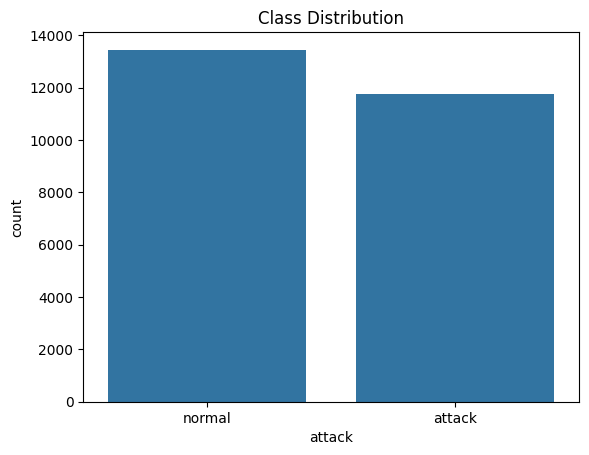

In [24]:
import seaborn as sns

print("\nClass distribution:")
print(df['attack'].value_counts())

sns.countplot(x='attack', data=df)
plt.title("Class Distribution")
plt.savefig('dd.png')
plt.show()


## split data to X and Y

In [ ]:
# Séparation des caractéristiques et de la cible
X = df.drop('attack', axis=1)
y = df['attack']

## Normalize data

In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['protocol_type', 'service', 'flag'], dtype='object')


In [ ]:
X_encoded = pd.get_dummies(X, columns=categorical_cols)
# Turn y into binary: 0 = normal, 1 = attack
#y_binary = y.apply(lambda x: 0 if x == 'normal' else 1)

## Pytorch

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

import pennylane as qml
from pennylane.qnn import TorchLayer

/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [ ]:
from sklearn.preprocessing import StandardScaler
# Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [ ]:
# 🔤 Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) # 0 = attack , 1 = normal
#y_bin_encoded = label_encoder.fit_transform(y_binary)

## **SMOTE is optional**

In [ ]:
# 🔄 SMOTE (optional but common for IDS datasets)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y_encoded)

# 🔢 Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# **QRL**

# **3rd version with real NSL-KDD Dataset**

In [ ]:
"""
qrl_ids_pipeline.py
Complete demo pipeline for QRL-IDS:
- Synthetic dataset (placeholder for CICIDS2017)
- StandardScaler -> PCA to n_qubits dims
- Gym-like streaming environment with reward shaping
- Classical REINFORCE baseline (PyTorch)
- Hybrid QNN policy (PennyLane + TorchLayer)
- Train both and save results for analysis

Replace the synthetic dataset with your CICIDS2017 preprocessing
if you want to run on real data (see comments).
"""

import os
import numpy as np
import random
import pickle
import argparse
from collections import deque
from time import time
import torch
import torch.nn as nn
import torch.optim as optim

# try/except to give a nice message if PennyLane isn't installed
try:
    import pennylane as qml
    from pennylane.qnn import TorchLayer
except Exception as e:
    qml = None
    TorchLayer = None
    print("Warning: PennyLane not found. Hybrid QNN will not run unless you install pennylane.")
    print("Install with: pip install pennylane")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
# -------------------------
# Config / Hyperparameters
# -------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

N_SAMPLES = 25000
ORIG_DIMS = 30
N_QUBITS = 2
N_ACTIONS = 2  # 0 = ignore (benign), 1 = alert (attack)
EPISODE_LENGTH = 200
TRAIN_EPISODES = 1000
GAMMA = 0.99
LR = 1e-3
N_LAYERS_QNN = 2  # ansatz depth for QNN

OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/Angle-pca2/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# -------------------------
# Utility functions
# -------------------------
def generate_synthetic_dataset(n_samples=5000, orig_dims=30, attack_ratio=0.18):
    n_attack = int(n_samples * attack_ratio)
    n_benign = n_samples - n_attack
    benign = np.random.normal(loc=0.0, scale=1.0, size=(n_benign, orig_dims))
    attack = np.random.normal(loc=1.5, scale=1.2, size=(n_attack, orig_dims))
    X = np.vstack([benign, attack])
    y = np.hstack([np.zeros(n_benign, dtype=int), np.ones(n_attack, dtype=int)])
    idx = np.arange(n_samples)
    np.random.shuffle(idx)
    return X[idx], y[idx]

def compute_metrics(true_labels, pred_labels):
    acc = accuracy_score(true_labels, pred_labels)
    p, r, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='binary', zero_division=0)
    cm = confusion_matrix(true_labels, pred_labels)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1, "confusion_matrix": cm}

In [ ]:
# -------------------------
# Env: Gym-like streaming
# -------------------------
class IDSStreamEnv:
    def __init__(self, X, y, episode_length=200, shuffle=True, seed=None):
        self.X = X
        self.y = y
        self.n = len(X)
        self.episode_length = episode_length
        self.shuffle = shuffle
        self.rng = np.random.RandomState(seed)
        self.order = np.arange(self.n)
        if self.shuffle:
            self.rng.shuffle(self.order)
        self.reset()

    def reset(self):
        start = self.rng.randint(0, max(1, self.n - self.episode_length))
        self.cur_idx = start
        self.steps = 0
        state = self.X[self.order[self.cur_idx]]
        return state.astype(np.float32)

    def step(self, action):
        label = self.y[self.order[self.cur_idx]]
        # reward shaping (tune these numbers to your needs)
        if action == 1 and label == 1:  # true positive
            reward = 2.0
        elif action == 0 and label == 1:  # false negative (miss)
            reward = -2.0
        elif action == 1 and label == 0:  # false positive
            reward = -0.5
        else:  # action == 0 and label == 0 (true negative)
            reward = 2.0
        self.cur_idx += 1
        self.steps += 1
        done = self.steps >= self.episode_length or self.cur_idx >= self.n
        if not done:
            next_state = self.X[self.order[self.cur_idx]].astype(np.float32)
        else:
            next_state = np.zeros_like(self.X[0], dtype=np.float32)
        return next_state, float(reward), done, {"label": int(label)}

In [ ]:
# -------------------------
# Policies
# -------------------------
class ClassicalPolicy(nn.Module):
    def __init__(self, input_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions)
        )

    def forward(self, x):
        logits = self.net(x)
        return torch.softmax(logits, dim=-1)

def build_hybrid_policy(n_qubits, n_actions, n_layers=2):
    if qml is None:
        raise RuntimeError("PennyLane is required to build hybrid policy. pip install pennylane.")
    dev = qml.device("default.qubit", wires=n_qubits, shots=None)
    def qnode(inputs, weights):
        qml.templates.AngleEmbedding(inputs, wires=range(n_qubits))
        qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    weight_shapes = {"weights": (n_layers, n_qubits, 3)}
    #qnode_torch = qml.QNode(qnode, dev, interface='torch', diff_method='parameter-shift')
    qnode_torch = qml.QNode(qnode, dev, interface='torch', diff_method='backprop')

    qlayer = TorchLayer(qnode_torch, weight_shapes)

    class HybridPolicy(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc_in = nn.Linear(n_qubits, n_qubits)
            self.ql = qlayer
            self.fc_out = nn.Sequential(
                nn.Linear(n_qubits, 32),
                nn.Tanh(),
                nn.Linear(32, n_actions)
            )
        def forward(self, x):
            x = torch.tanh(self.fc_in(x))
            x = self.ql(x)
            logits = self.fc_out(x)
            return torch.softmax(logits, dim=-1)
    return HybridPolicy()

In [ ]:
# -------------------------
# REINFORCE training routine
# -------------------------
def reinforce_train(env, policy, optimizer, episodes=100, max_steps=200, gamma=0.99, name="policy"):
    all_episode_rewards = []
    metrics_history = []
    for ep in range(episodes):
        start_time = time()  # Start time for the episode
        log_probs = []
        rewards = []
        labels = []
        preds = []
        state = env.reset()
        for t in range(max_steps):
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            probs = policy(state_tensor).squeeze(0)
            m = torch.distributions.Categorical(probs)
            action = m.sample()
            log_prob = m.log_prob(action)
            next_state, reward, done, info = env.step(int(action.item()))
            log_probs.append(log_prob)
            rewards.append(reward)
            labels.append(info["label"])
            preds.append(int(action.item()))
            state = next_state
            if done:
                break
        # compute discounted returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32)
        if returns.size(0) > 1 and returns.std().item() > 1e-8:
            returns = (returns - returns.mean()) / (returns.std() + 1e-9)
        loss = 0
        for log_prob, Gt in zip(log_probs, returns):
            loss -= log_prob * Gt
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_reward = sum(rewards)
        all_episode_rewards.append(total_reward)
        metrics = compute_metrics(np.array(labels), np.array(preds))
        metrics_history.append(metrics)
        end_time = time()  # End time for the episode
        episode_duration = end_time - start_time
        if (ep + 1) % 10 == 0 or ep == 0:
            print(f"[{name}] Episode {ep+1}/{episodes}  Reward: {total_reward:.2f}  Acc: {metrics['accuracy']:.3f}  F1: {metrics['f1']:.3f}  Time: {episode_duration:.2f}s")
    return all_episode_rewards, metrics_history

# **old**

In [ ]:
# -------------------------
# Main pipeline (synthetic data)
# -------------------------
def main():
    # 1) Data: synthetic (replace with real CICIDS loader if available)
    #X, y = generate_synthetic_dataset(N_SAMPLES, ORIG_DIMS, attack_ratio=0.18)


    # If you have CICIDS2017 CSV(s), replace generation with something like:
    # import pandas as pd
    # df = pd.read_csv("data/cicids_combined.csv")
    # df = df.dropna()  # handle missing
    # numeric_cols = [c for c in df.columns if df[c].dtype != 'object']
    # X = df[numeric_cols].values
    # # convert label to binary: e.g., df['Label'] == 'BENIGN' -> 0 else 1
    # y = (df['Label'] != 'BENIGN').astype(int).values
    print("Data shapes:", X.shape, y.shape, "Attack ratio:", y_encoded.mean())

    # 2) Preprocess: scaler -> PCA
    #scaler = StandardScaler()
    #X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=N_QUBITS)
    X_pca = pca.fit_transform(X_scaled)
    print("PCA shape:", X_pca.shape)

    # 3) Build envs
    env_classical = IDSStreamEnv(X_pca,y_encoded, episode_length=EPISODE_LENGTH, shuffle=True, seed=1)
    env_hybrid = IDSStreamEnv(X_pca, y_encoded, episode_length=EPISODE_LENGTH, shuffle=True, seed=2)

    # 4) Classical baseline
    classical_policy = ClassicalPolicy(N_QUBITS, N_ACTIONS)
    optimizer_c = optim.Adam(classical_policy.parameters(), lr=LR)
    print("Training classical REINFORCE baseline...")
    rewards_classical, metrics_classical = reinforce_train(env_classical, classical_policy, optimizer_c,
                                                           episodes=TRAIN_EPISODES, max_steps=EPISODE_LENGTH, gamma=GAMMA,
                                                           name="Classical")

    # 5) Hybrid QNN (wit PennyLane)
    if qml is None:
        print("Skipping hybrid QNN training because PennyLane is not installed.")
        rewards_hybrid, metrics_hybrid = [], []
    else:
        hybrid_policy = build_hybrid_policy(N_QUBITS, N_ACTIONS, n_layers=N_LAYERS_QNN)
        optimizer_h = optim.Adam(hybrid_policy.parameters(), lr=LR)
        print("Training hybrid QNN REINFORCE policy...")
        rewards_hybrid, metrics_hybrid = reinforce_train(env_hybrid, hybrid_policy, optimizer_h,
                                                         episodes=TRAIN_EPISODES, max_steps=EPISODE_LENGTH, gamma=GAMMA,
                                                         name="Hybrid-QNN")

    # 6) Save results
    results = {
        "rewards_classical": rewards_classical,
        "metrics_classical": metrics_classical,
        "rewards_hybrid": rewards_hybrid,
        "metrics_hybrid": metrics_hybrid,
        "scaler": scaler,
        "pca": pca,
        "config": {
            "n_qubits": N_QUBITS,
            "orig_dims": ORIG_DIMS,
            "episode_length": EPISODE_LENGTH,
            "train_episodes": TRAIN_EPISODES
        }
    }
    with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "wb") as f:
        pickle.dump(results, f)
    print("Saved results to", os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"))

    # 7) Quick plots (reward curves)
    plt.figure(figsize=(8,4))
    if len(rewards_classical) > 0:
        plt.plot(rewards_classical, label="Classical (REINFORCE)")
    if len(rewards_hybrid) > 0:
        plt.plot(rewards_hybrid, label="Hybrid QNN (REINFORCE)")
    plt.title("Episode rewards")
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "rewards_curve.png"))
    print("Saved reward plot to", os.path.join(OUTPUT_DIR, "rewards_curve.png"))

        # 8) Metrics visualization (Accuracy, F1, Confusion Matrix)
    def plot_metric(metric_name, classical_metrics, hybrid_metrics, save_path):
        plt.figure(figsize=(8,4))
        plt.plot([m[metric_name] for m in classical_metrics], label="Classical", color='blue')
        if len(hybrid_metrics) > 0:
            plt.plot([m[metric_name] for m in hybrid_metrics], label="Hybrid QNN", color='orange')
        plt.title(f"{metric_name.capitalize()} over Episodes")
        plt.xlabel("Episode")
        plt.ylabel(metric_name.capitalize())
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(save_path)
        print(f"Saved {metric_name} plot to {save_path}")
        plt.close()

    # Plot Accuracy
    plot_metric("accuracy", metrics_classical, metrics_hybrid, os.path.join(OUTPUT_DIR, "accuracy_curve.png"))

    # Plot F1-score
    plot_metric("f1", metrics_classical, metrics_hybrid, os.path.join(OUTPUT_DIR, "f1_curve.png"))

    # 9) Confusion matrix (last episode)
    def plot_confusion_matrix(cm, title, save_path):
        plt.figure(figsize=(4,4))
        plt.imshow(cm, cmap='Blues')
        plt.title(title)
        plt.colorbar()
        plt.xticks([0,1], ['Benign','Attack'])
        plt.yticks([0,1], ['Benign','Attack'])
        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i,j], ha='center', va='center', color='black', fontsize=12)
        plt.tight_layout()
        plt.savefig(save_path)
        print(f"Saved {title} confusion matrix to {save_path}")
        plt.close()

    # Confusion matrices for last episodes
    cm_classical = metrics_classical[-1]['confusion_matrix']
    plot_confusion_matrix(cm_classical, "Classical Confusion Matrix", os.path.join(OUTPUT_DIR, "cm_classical.png"))

    if len(metrics_hybrid) > 0:
        cm_hybrid = metrics_hybrid[-1]['confusion_matrix']
        plot_confusion_matrix(cm_hybrid, "Hybrid QNN Confusion Matrix", os.path.join(OUTPUT_DIR, "cm_hybrid.png"))

    print("All plots saved in", OUTPUT_DIR)

# **new version + FN Score and test samples**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import os, pickle, matplotlib.pyplot as plt
import torch.optim as optim
pi = np.pi

# -------------------------
# Main pipeline (synthetic or CICIDS)
# -------------------------
def main():
    # 1) Load or generate data
    # X, y = generate_synthetic_dataset(N_SAMPLES, ORIG_DIMS, attack_ratio=0.18)

    # Example with CICIDS dataset:
    # df = pd.read_csv("data/cicids_combined.csv")
    # df = df.dropna()
    # numeric_cols = [c for c in df.columns if df[c].dtype != 'object']
    # X = df[numeric_cols].values
    # y = (df["Label"] != "BENIGN").astype(int).values

    print("Data shapes:", X.shape, y.shape, "Attack ratio:", y_encoded.mean())


    pca = PCA(n_components=N_QUBITS)
    X_pca = pca.fit_transform(X_scaled)
    print("PCA shape:", X_pca.shape)

    # Normalize PCA output to [0, 2π] for angle embedding
    #X_min, X_max = X_pca.min(), X_pca.max()
    #X_pca_scaled = 2 * pi * (X_pca - X_min) / (X_max - X_min)

    # 3) Split into train/test sets for classical
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y_encoded, test_size=0.2, random_state=42, stratify=y)
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")

    # 4) Build separate environments
    env_train_classical = IDSStreamEnv(X_train, y_train, episode_length=EPISODE_LENGTH, shuffle=True, seed=1)
    env_train_hybrid = IDSStreamEnv(X_train, y_train, episode_length=EPISODE_LENGTH, shuffle=True, seed=2)
    env_test_classical = IDSStreamEnv(X_test, y_test, episode_length=len(X_test), shuffle=False)
    env_test_hybrid = IDSStreamEnv(X_test, y_test, episode_length=len(X_test), shuffle=False)

    # 5) Classical REINFORCE
    classical_policy = ClassicalPolicy(N_QUBITS, N_ACTIONS)
    optimizer_c = optim.Adam(classical_policy.parameters(), lr=LR)
    print("Training classical REINFORCE baseline...")
    rewards_classical, metrics_classical = reinforce_train(
        env_train_classical, classical_policy, optimizer_c,
        episodes=TRAIN_EPISODES, max_steps=EPISODE_LENGTH, gamma=GAMMA, name="Classical"
    )

    # 6) Hybrid Quantum Neural Network REINFORCE
    if qml is None:
        print("Skipping hybrid QNN training because PennyLane is not installed.")
        rewards_hybrid, metrics_hybrid = [], []
    else:
        hybrid_policy = build_hybrid_policy(N_QUBITS, N_ACTIONS, n_layers=N_LAYERS_QNN)
        optimizer_h = optim.Adam(hybrid_policy.parameters(), lr=LR)
        print("Training hybrid QNN REINFORCE policy...")
        rewards_hybrid, metrics_hybrid = reinforce_train(
            env_train_hybrid, hybrid_policy, optimizer_h,
            episodes=TRAIN_EPISODES, max_steps=EPISODE_LENGTH, gamma=GAMMA, name="Hybrid-QNN"
        )

    # 7) Evaluate on test set
    def evaluate_model(env, policy, name):
        all_preds, all_true = [], []
        for X_batch, y_batch in zip(env.X, env.y):
            X_tensor = torch.tensor(X_batch, dtype=torch.float32)
            with torch.no_grad():
                probs = policy(X_tensor)
            pred = torch.argmax(probs).item()
            all_preds.append(pred)
            all_true.append(int(y_batch))

        acc = accuracy_score(all_true, all_preds)
        prec = precision_score(all_true, all_preds, zero_division=0)
        rec = recall_score(all_true, all_preds, zero_division=0)
        f1 = f1_score(all_true, all_preds, zero_division=0)
        cm = confusion_matrix(all_true, all_preds)
        tn, fp, fn, tp = cm.ravel()
        #tnr = tn / (tn + fp)
        #fpr = fp / (fp + tn)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0      # False Positive Rate
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0      # False Negative Rate

        metrics = {
            "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

        print(f"{name} Test Metrics: {metrics}")

        metrics = {
            "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
            "false_negative_rate": fnr, "false_positive_rate": fpr,"confusion_matrix": cm
        }
        return metrics

    metrics_test_classical = evaluate_model(env_test_classical, classical_policy, "Classical")
    metrics_test_hybrid = evaluate_model(env_test_hybrid, hybrid_policy, "Hybrid-QNN") if len(metrics_hybrid) > 0 else {}

    # 8) Save results
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    results = {
        "rewards_classical": rewards_classical,
        "metrics_classical": metrics_classical,
        "rewards_hybrid": rewards_hybrid,
        "metrics_hybrid": metrics_hybrid,
        "test_classical": metrics_test_classical,
        "test_hybrid": metrics_test_hybrid,
        "scaler": scaler,
        "pca": pca
    }
    with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "wb") as f:
        pickle.dump(results, f)
    print(f"Saved results to {OUTPUT_DIR}/qrl_ids_results.pkl")

    # 9) Save metrics to CSV
    df_classical = pd.DataFrame(metrics_classical)
    df_hybrid = pd.DataFrame(metrics_hybrid)
    df_classical.to_csv(os.path.join(OUTPUT_DIR, "train_metrics_classical.csv"), index=False)
    if len(metrics_hybrid) > 0:
        df_hybrid.to_csv(os.path.join(OUTPUT_DIR, "train_metrics_hybrid.csv"), index=False)

    pd.DataFrame([metrics_test_classical]).to_csv(os.path.join(OUTPUT_DIR, "test_metrics_classical.csv"), index=False)
    if len(metrics_test_hybrid) > 0:
        pd.DataFrame([metrics_test_hybrid]).to_csv(os.path.join(OUTPUT_DIR, "test_metrics_hybrid.csv"), index=False)

    print("Saved metrics CSVs to", OUTPUT_DIR)

    # 10) Reward and performance plots
    plt.figure(figsize=(8,4))
    if len(rewards_classical) > 0:
        plt.plot(rewards_classical, label="Classical (REINFORCE)")
    if len(rewards_hybrid) > 0:
        plt.plot(rewards_hybrid, label="Hybrid QNN (REINFORCE)")
    plt.title("Episode Rewards")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "rewards_curve.png"))
    plt.close()

    def plot_metric(metric_name, classical_metrics, hybrid_metrics, save_path):
        plt.figure(figsize=(8,4))
        plt.plot([m[metric_name] for m in classical_metrics], label="Classical", color='blue')
        if len(hybrid_metrics) > 0:
            plt.plot([m[metric_name] for m in hybrid_metrics], label="Hybrid QNN", color='orange')
        plt.title(f"{metric_name.capitalize()} over Episodes")
        plt.xlabel("Episode"); plt.ylabel(metric_name.capitalize())
        plt.legend(); plt.grid(True); plt.tight_layout()
        plt.savefig(save_path); plt.close()

    plot_metric("accuracy", metrics_classical, metrics_hybrid, os.path.join(OUTPUT_DIR, "accuracy_curve.png"))
    plot_metric("f1", metrics_classical, metrics_hybrid, os.path.join(OUTPUT_DIR, "f1_curve.png"))

    def plot_confusion_matrix(cm, title, save_path):
        plt.figure(figsize=(4,4))
        plt.imshow(cm, cmap='Blues')
        plt.title(title)
        plt.colorbar()
        plt.xticks([0,1], ['Benign','Attack'])
        plt.yticks([0,1], ['Benign','Attack'])
        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i,j], ha='center', va='center', color='black', fontsize=12)
        plt.tight_layout()
        plt.savefig(save_path)
        plt.close()

    plot_confusion_matrix(metrics_test_classical["confusion_matrix"], "Classical Test Confusion Matrix", os.path.join(OUTPUT_DIR, "cm_test_classical.png"))
    if len(metrics_test_hybrid) > 0:
        plot_confusion_matrix(metrics_test_hybrid["confusion_matrix"], "Hybrid QNN Test Confusion Matrix", os.path.join(OUTPUT_DIR, "cm_test_hybrid.png"))

    print(f"\n✅ Training and evaluation complete! Results and plots saved in {OUTPUT_DIR}\n")


PCA 2

In [ ]:
if __name__ == "__main__":
    main()

Data shapes: (25191, 42) (25191,) Attack ratio: 0.5338414513119765
PCA shape: (25191, 2)
Train Classical: (20152, 2), Test Classical: (5039, 2)
Train Hybrid: (20152, 2), Test Hybrid: (5039, 2)
Training classical REINFORCE baseline...
[Classical] Episode 1/1000  Reward: 113.50  Acc: 0.550  F1: 0.628  Time: 0.20s
[Classical] Episode 10/1000  Reward: 127.50  Acc: 0.575  F1: 0.615  Time: 0.18s
[Classical] Episode 20/1000  Reward: 192.50  Acc: 0.660  F1: 0.702  Time: 0.18s
[Classical] Episode 30/1000  Reward: 203.50  Acc: 0.670  F1: 0.732  Time: 0.18s
[Classical] Episode 40/1000  Reward: 241.00  Acc: 0.715  F1: 0.771  Time: 0.26s
[Classical] Episode 50/1000  Reward: 272.50  Acc: 0.760  F1: 0.818  Time: 0.21s
[Classical] Episode 60/1000  Reward: 206.50  Acc: 0.640  F1: 0.723  Time: 0.18s
[Classical] Episode 70/1000  Reward: 258.00  Acc: 0.725  F1: 0.776  Time: 0.19s
[Classical] Episode 80/1000  Reward: 264.00  Acc: 0.740  F1: 0.795  Time: 0.20s
[Classical] Episode 90/1000  Reward: 258.00  Ac

In [ ]:
if __name__ == "__main__":
    main()

Data shapes: (25191, 42) (25191,) Attack ratio: 0.5338414513119765
PCA shape: (25191, 2)
Train: (20152, 2), Test: (5039, 2)
Training classical REINFORCE baseline...
[Classical] Episode 1/1000  Reward: 13.50  Acc: 0.440  F1: 0.451  Time: 0.21s
[Classical] Episode 10/1000  Reward: 179.50  Acc: 0.670  F1: 0.683  Time: 0.20s
[Classical] Episode 20/1000  Reward: 184.00  Acc: 0.670  F1: 0.683  Time: 0.20s
[Classical] Episode 30/1000  Reward: 203.50  Acc: 0.700  F1: 0.727  Time: 0.26s
[Classical] Episode 40/1000  Reward: 214.00  Acc: 0.715  F1: 0.732  Time: 0.20s
[Classical] Episode 50/1000  Reward: 242.00  Acc: 0.765  F1: 0.785  Time: 0.21s
[Classical] Episode 60/1000  Reward: 264.00  Acc: 0.770  F1: 0.795  Time: 0.21s
[Classical] Episode 70/1000  Reward: 260.00  Acc: 0.780  F1: 0.780  Time: 0.59s
[Classical] Episode 80/1000  Reward: 264.50  Acc: 0.780  F1: 0.800  Time: 0.21s
[Classical] Episode 90/1000  Reward: 301.50  Acc: 0.845  F1: 0.841  Time: 0.29s
[Classical] Episode 100/1000  Reward:

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/Angle-pca2/fpr_fnr_per_episode.csv


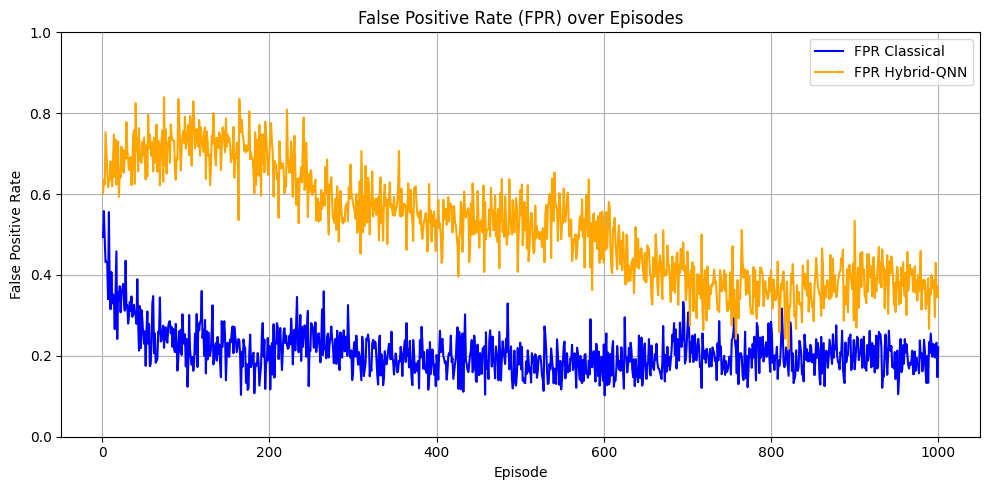

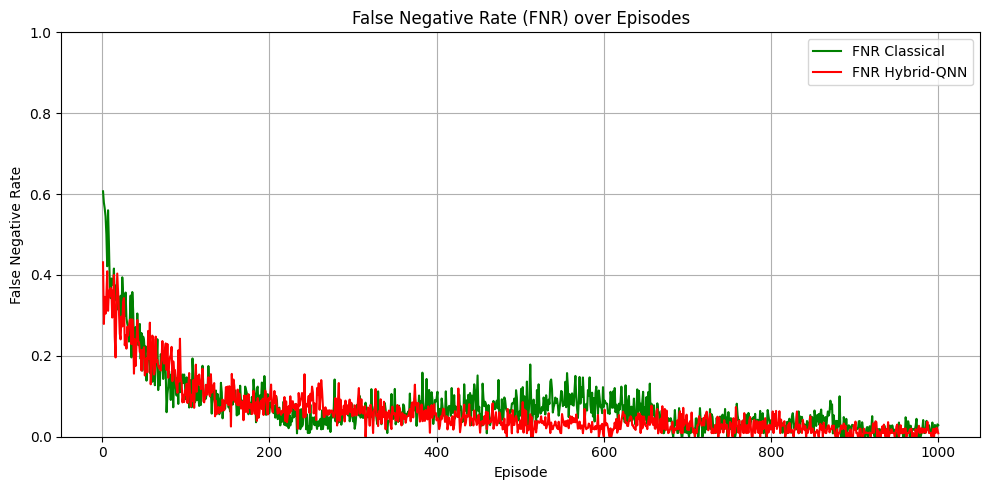

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/Angle-pca2/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# **PCA 4**

In [ ]:
# -------------------------
# Config / Hyperparameters
# -------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

N_SAMPLES = 25000
ORIG_DIMS = 30
N_QUBITS = 4
N_ACTIONS = 2  # 0 = ignore (benign), 1 = alert (attack)
EPISODE_LENGTH = 200
TRAIN_EPISODES = 1000
GAMMA = 0.99
LR = 1e-3
N_LAYERS_QNN = 2  # ansatz depth for QNN

OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/Angle-pca4/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
if __name__ == "__main__":
    main()

Data shapes: (25191, 42) (25191,) Attack ratio: 0.5338414513119765
PCA shape: (25191, 4)
Train: (20152, 4), Test: (5039, 4)
Training classical REINFORCE baseline...
[Classical] Episode 1/1000  Reward: 56.50  Acc: 0.490  F1: 0.532  Time: 0.29s
[Classical] Episode 10/1000  Reward: 80.50  Acc: 0.505  F1: 0.548  Time: 0.20s
[Classical] Episode 20/1000  Reward: 145.50  Acc: 0.590  F1: 0.637  Time: 0.21s
[Classical] Episode 30/1000  Reward: 186.50  Acc: 0.645  F1: 0.710  Time: 0.20s
[Classical] Episode 40/1000  Reward: 225.50  Acc: 0.720  F1: 0.750  Time: 0.21s
[Classical] Episode 50/1000  Reward: 221.00  Acc: 0.720  F1: 0.757  Time: 0.24s
[Classical] Episode 60/1000  Reward: 224.00  Acc: 0.720  F1: 0.738  Time: 0.28s
[Classical] Episode 70/1000  Reward: 232.50  Acc: 0.725  F1: 0.739  Time: 0.22s
[Classical] Episode 80/1000  Reward: 250.00  Acc: 0.760  F1: 0.780  Time: 0.22s
[Classical] Episode 90/1000  Reward: 289.50  Acc: 0.815  F1: 0.820  Time: 0.22s
[Classical] Episode 100/1000  Reward: 

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/Angle-pca4/fpr_fnr_per_episode.csv


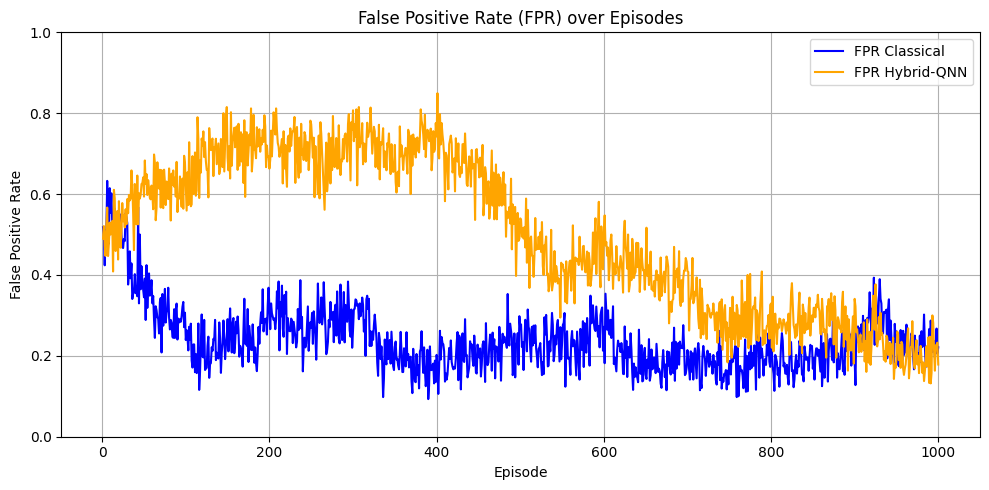

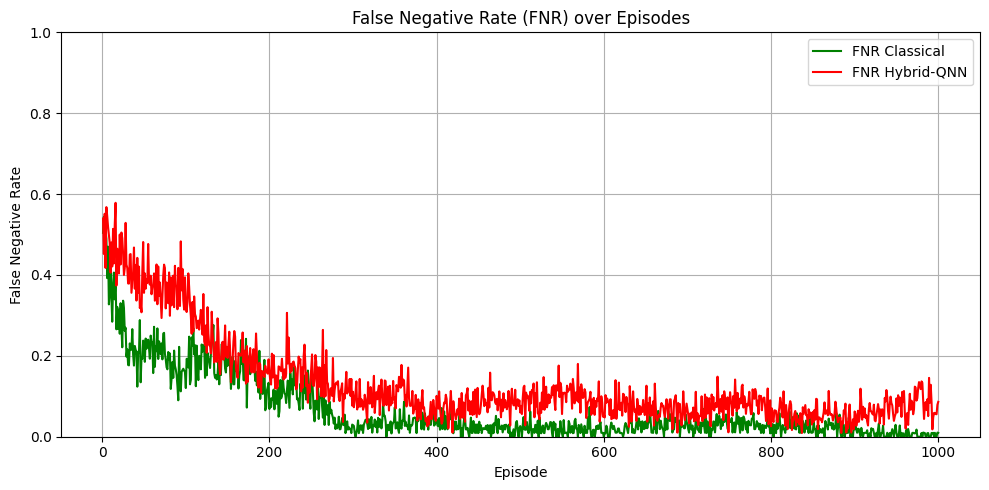

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/Angle-pca4/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# **pca 6**

In [ ]:
# -------------------------
# Config / Hyperparameters
# -------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

N_SAMPLES = 25000
ORIG_DIMS = 30
N_QUBITS = 6
N_ACTIONS = 2  # 0 = ignore (benign), 1 = alert (attack)
EPISODE_LENGTH = 200
TRAIN_EPISODES = 1000
GAMMA = 0.99
LR = 1e-3
N_LAYERS_QNN = 2  # ansatz depth for QNN

OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/Angle-pca6/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
if __name__ == "__main__":
    main()

Data shapes: (25191, 42) (25191,) Attack ratio: 0.5338414513119765
PCA shape: (25191, 6)
Train: (20152, 6), Test: (5039, 6)
Training classical REINFORCE baseline...
[Classical] Episode 1/1000  Reward: 37.50  Acc: 0.455  F1: 0.511  Time: 0.25s
[Classical] Episode 10/1000  Reward: 86.50  Acc: 0.535  F1: 0.537  Time: 0.30s
[Classical] Episode 20/1000  Reward: 151.00  Acc: 0.610  F1: 0.639  Time: 0.24s
[Classical] Episode 30/1000  Reward: 184.50  Acc: 0.665  F1: 0.702  Time: 0.30s
[Classical] Episode 40/1000  Reward: 169.00  Acc: 0.640  F1: 0.670  Time: 0.23s
[Classical] Episode 50/1000  Reward: 193.50  Acc: 0.680  F1: 0.719  Time: 0.27s
[Classical] Episode 60/1000  Reward: 194.50  Acc: 0.655  F1: 0.701  Time: 0.30s
[Classical] Episode 70/1000  Reward: 279.00  Acc: 0.785  F1: 0.805  Time: 0.22s
[Classical] Episode 80/1000  Reward: 262.00  Acc: 0.760  F1: 0.795  Time: 0.26s
[Classical] Episode 90/1000  Reward: 268.00  Acc: 0.760  F1: 0.786  Time: 0.22s
[Classical] Episode 100/1000  Reward: 

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/Angle-pca6/fpr_fnr_per_episode.csv


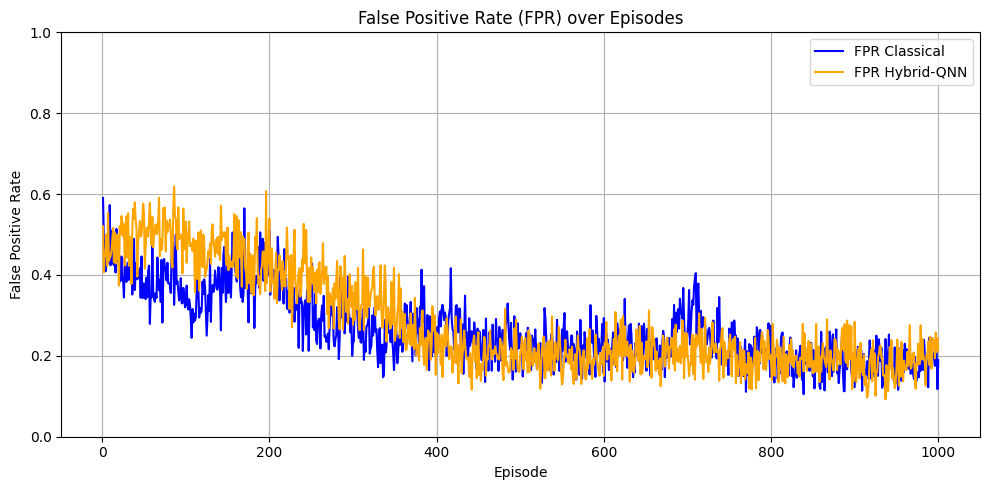

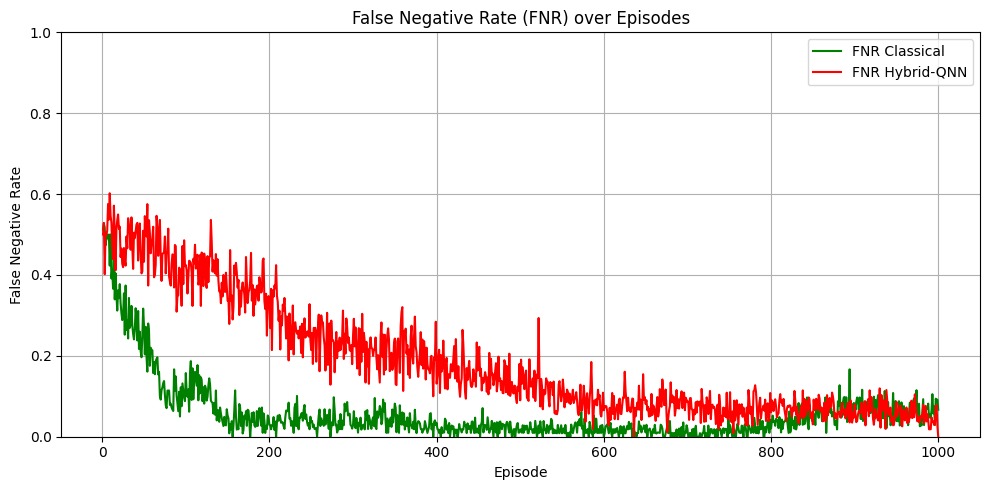

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/Angle-pca6/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# **pca 8**

In [ ]:
# -------------------------
# Config / Hyperparameters
# -------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

N_SAMPLES = 25000
ORIG_DIMS = 30
N_QUBITS = 8
N_ACTIONS = 2  # 0 = ignore (benign), 1 = alert (attack)
EPISODE_LENGTH = 200
TRAIN_EPISODES = 1000
GAMMA = 0.99
LR = 1e-3
N_LAYERS_QNN = 2  # ansatz depth for QNN

OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/Angle-pca8/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
if __name__ == "__main__":
    main()

Data shapes: (25191, 42) (25191,) Attack ratio: 0.5338414513119765
PCA shape: (25191, 8)
Train: (20152, 8), Test: (5039, 8)
Training classical REINFORCE baseline...
[Classical] Episode 1/1000  Reward: 120.50  Acc: 0.585  F1: 0.624  Time: 0.59s
[Classical] Episode 10/1000  Reward: 142.00  Acc: 0.595  F1: 0.637  Time: 0.42s
[Classical] Episode 20/1000  Reward: 176.00  Acc: 0.630  F1: 0.681  Time: 0.55s
[Classical] Episode 30/1000  Reward: 215.00  Acc: 0.675  F1: 0.747  Time: 0.34s
[Classical] Episode 40/1000  Reward: 202.00  Acc: 0.670  F1: 0.720  Time: 0.32s
[Classical] Episode 50/1000  Reward: 254.50  Acc: 0.745  F1: 0.798  Time: 0.61s
[Classical] Episode 60/1000  Reward: 195.50  Acc: 0.645  F1: 0.705  Time: 0.18s
[Classical] Episode 70/1000  Reward: 260.00  Acc: 0.735  F1: 0.778  Time: 0.18s
[Classical] Episode 80/1000  Reward: 248.00  Acc: 0.720  F1: 0.776  Time: 0.19s
[Classical] Episode 90/1000  Reward: 247.50  Acc: 0.710  F1: 0.758  Time: 0.19s
[Classical] Episode 100/1000  Reward

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/Angle-pca8/fpr_fnr_per_episode.csv


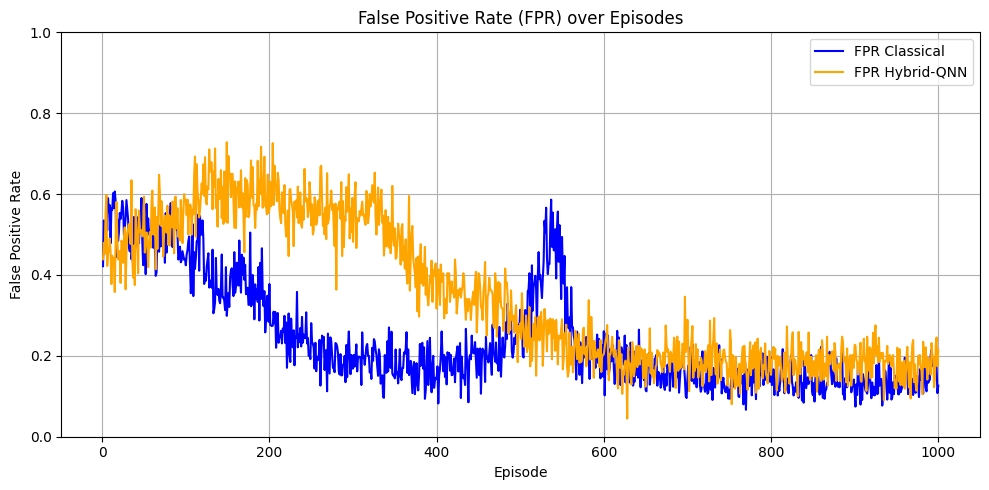

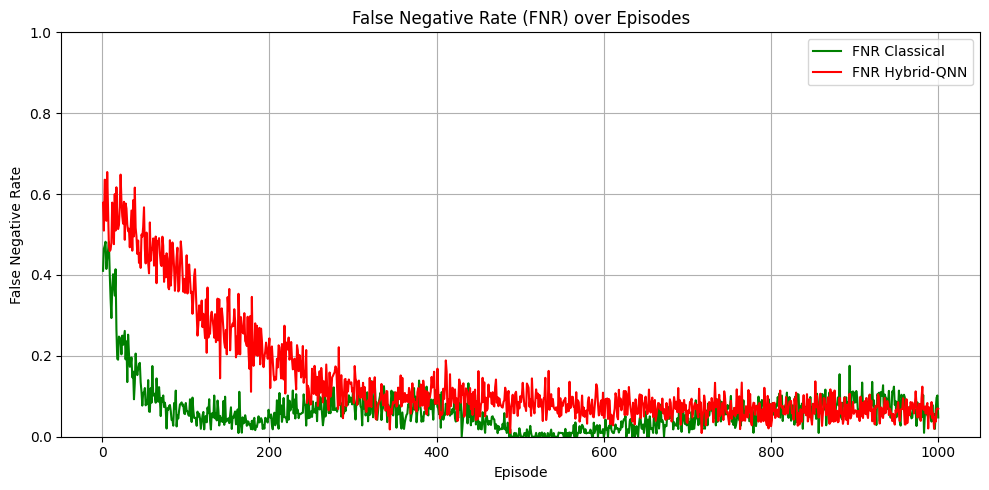

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/Angle-pca8/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# **PCA 10**

In [ ]:
# -------------------------
# Config / Hyperparameters
# -------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

N_SAMPLES = 25000
ORIG_DIMS = 30
N_QUBITS = 10
N_ACTIONS = 2  # 0 = ignore (benign), 1 = alert (attack)
EPISODE_LENGTH = 200
TRAIN_EPISODES = 1000
GAMMA = 0.99
LR = 1e-3
N_LAYERS_QNN = 2  # ansatz depth for QNN

OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/Angle-pca10/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
if __name__ == "__main__":
    main()

Data shapes: (25191, 42) (25191,) Attack ratio: 0.5338414513119765
PCA shape: (25191, 10)
Train: (20152, 10), Test: (5039, 10)
Training classical REINFORCE baseline...
[Classical] Episode 1/1000  Reward: 48.00  Acc: 0.485  F1: 0.512  Time: 0.20s
[Classical] Episode 10/1000  Reward: 99.00  Acc: 0.530  F1: 0.577  Time: 0.26s
[Classical] Episode 20/1000  Reward: 156.50  Acc: 0.630  F1: 0.641  Time: 0.18s
[Classical] Episode 30/1000  Reward: 109.00  Acc: 0.550  F1: 0.598  Time: 0.18s
[Classical] Episode 40/1000  Reward: 158.50  Acc: 0.610  F1: 0.661  Time: 0.17s
[Classical] Episode 50/1000  Reward: 212.50  Acc: 0.685  F1: 0.747  Time: 0.20s
[Classical] Episode 60/1000  Reward: 204.00  Acc: 0.650  F1: 0.718  Time: 0.18s
[Classical] Episode 70/1000  Reward: 201.50  Acc: 0.645  F1: 0.703  Time: 0.21s
[Classical] Episode 80/1000  Reward: 207.50  Acc: 0.660  F1: 0.726  Time: 0.24s
[Classical] Episode 90/1000  Reward: 227.50  Acc: 0.685  F1: 0.732  Time: 0.19s
[Classical] Episode 100/1000  Rewar

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/IQP-pca10/fpr_fnr_per_episode.csv


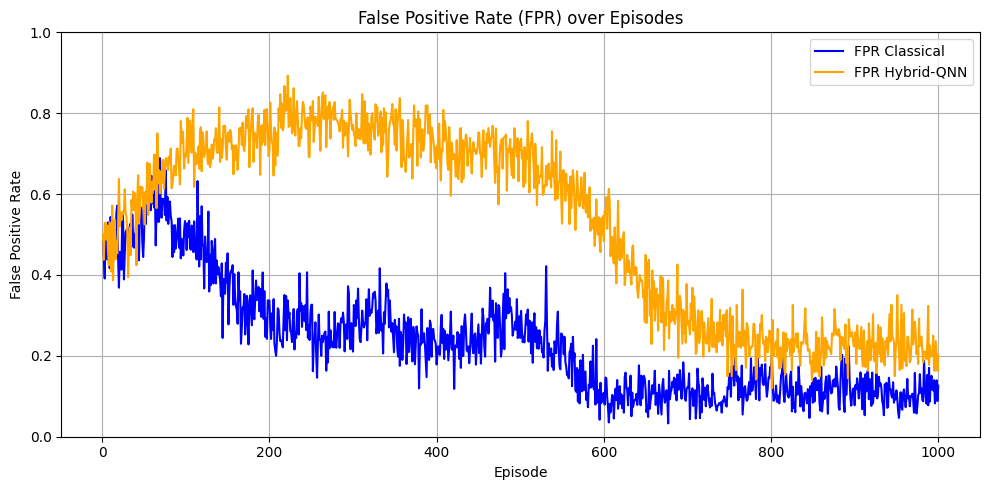

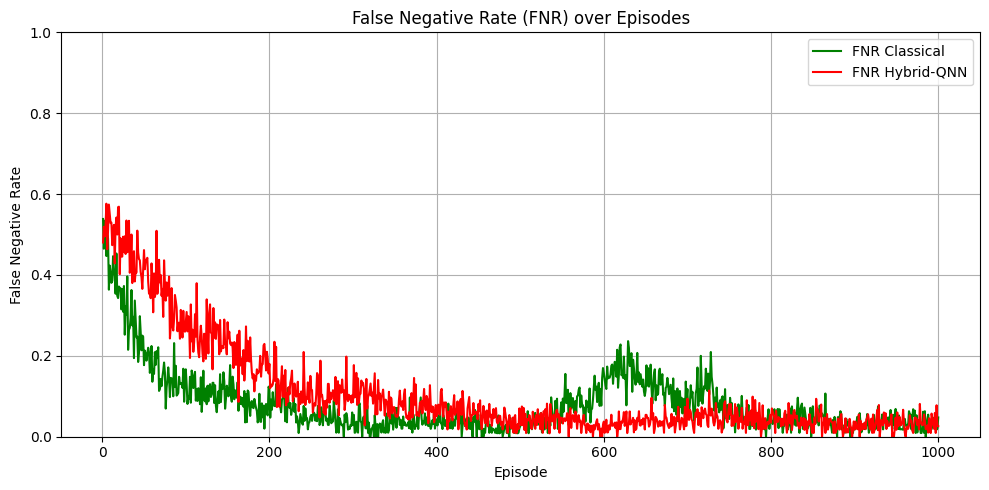

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/IQP-pca10/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# **Results**

In [ ]:
import pandas as pd

df_classical = pd.DataFrame(results["metrics_classical"])
df_hybrid = pd.DataFrame(results["metrics_hybrid"])

print(df_classical.head())


   accuracy  precision    recall        f1      confusion_matrix
0     0.525   0.578431  0.531532  0.553991  [[46, 43], [52, 59]]
1     0.470   0.485981  0.504854  0.495238  [[42, 55], [51, 52]]
2     0.495   0.461538  0.446809  0.454054  [[57, 49], [52, 42]]
3     0.500   0.556701  0.486486  0.519231  [[46, 43], [57, 54]]
4     0.565   0.584158  0.567308  0.575610  [[54, 42], [45, 59]]


ValueError: setting an array element with a sequence.

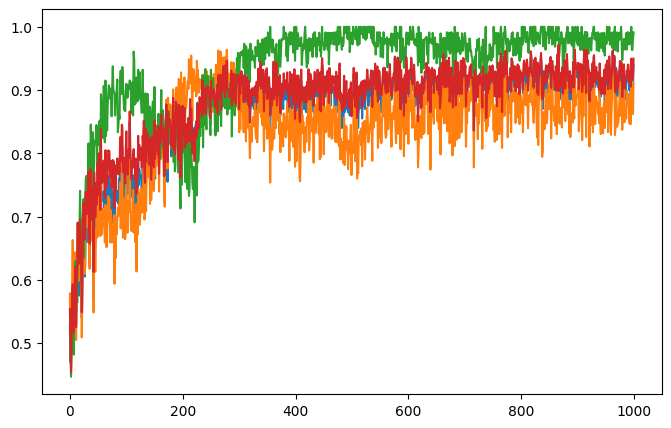

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for col in df_classical.columns:
    plt.plot(df_classical[col], label=f"Classical {col}")

for col in df_hybrid.columns:
    plt.plot(df_hybrid[col], '--', label=f"Hybrid {col}")

plt.xlabel("Episode")
plt.ylabel("Metric Value")
plt.title("Classical vs Hybrid QRL Performance")
plt.legend()
plt.show()


In [ ]:
last_classical = df_classical.iloc[-1]
last_hybrid = df_hybrid.iloc[-1]

summary = pd.DataFrame({
    "Classical": last_classical,
    "Hybrid QRL": last_hybrid
})
print(summary)


                             Classical            Hybrid QRL
accuracy                          0.94                 0.915
precision                      0.91129               0.87931
recall                        0.991228              0.971429
f1                             0.94958              0.923077
confusion_matrix  [[75, 11], [1, 113]]  [[81, 14], [3, 102]]


In [ ]:
import pickle
import matplotlib.pyplot as plt
import os

# Path to your saved file
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/IQP-pca8/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

# Access the test results
test_classical = results.get("test_classical", {})
test_hybrid = results.get("test_hybrid", {})

print("=== Keys in test_classical ===")
print(list(test_classical.keys()))

print("\n=== Keys in test_hybrid ===")
print(list(test_hybrid.keys()))


=== Keys in test_classical ===
['accuracy', 'precision', 'recall', 'f1', 'false_negative_rate', 'false_positive_rate', 'confusion_matrix']

=== Keys in test_hybrid ===
['accuracy', 'precision', 'recall', 'f1', 'false_negative_rate', 'false_positive_rate', 'confusion_matrix']


In [ ]:

print("Classical FPR:", test_classical["false_positive_rate"])
print("Classical FNR:", test_classical["false_negative_rate"])
print("Hybrid FPR:", test_hybrid["false_positive_rate"])
print("Hybrid FNR:", test_hybrid["false_negative_rate"])


Classical FPR: 0.16475095785440613
Classical FNR: 0.04907063197026022
Hybrid FPR: 0.17028522775649213
Hybrid FNR: 0.03308550185873606


# **PCA 2**

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/IQP-pca2/fpr_fnr_per_episode.csv


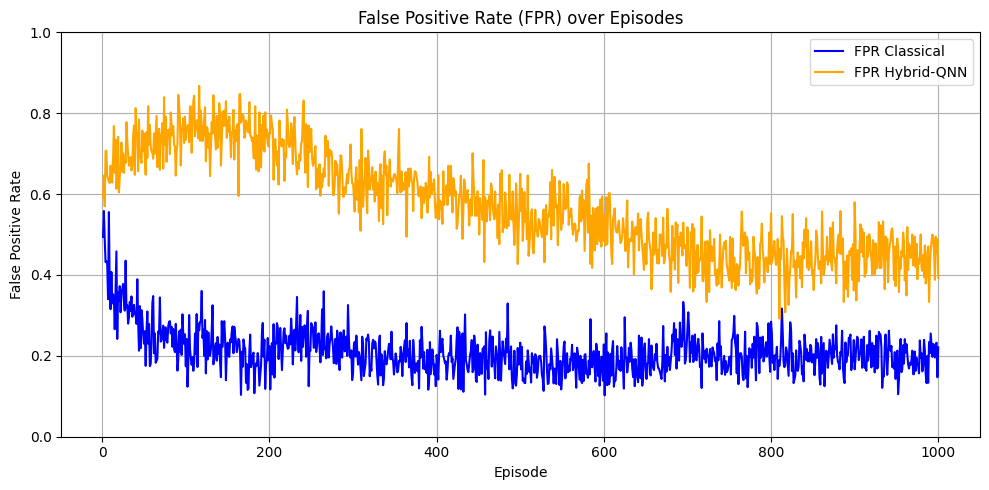

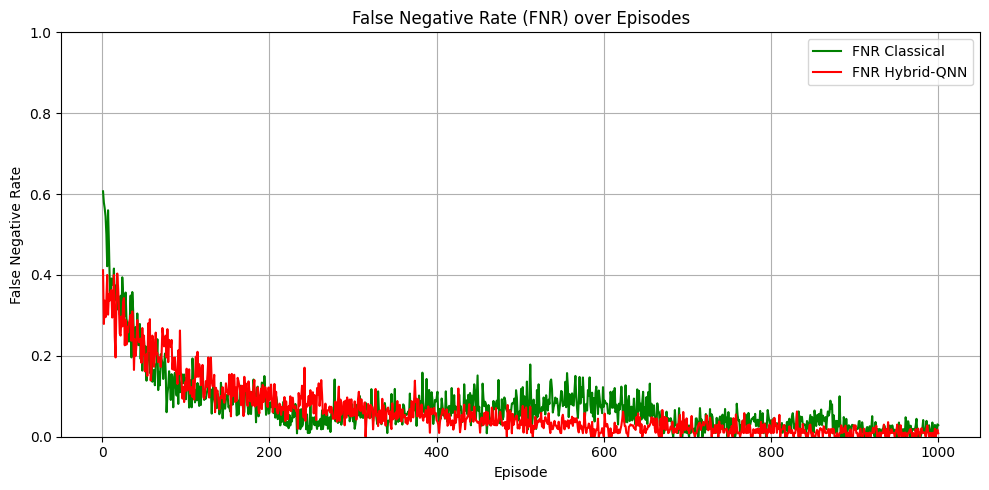

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/IQP-pca2/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        print(f"Processing episode {i+1}/{len(metrics)}")
        print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# **PCA 4**

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/IQP-pca4/fpr_fnr_per_episode.csv


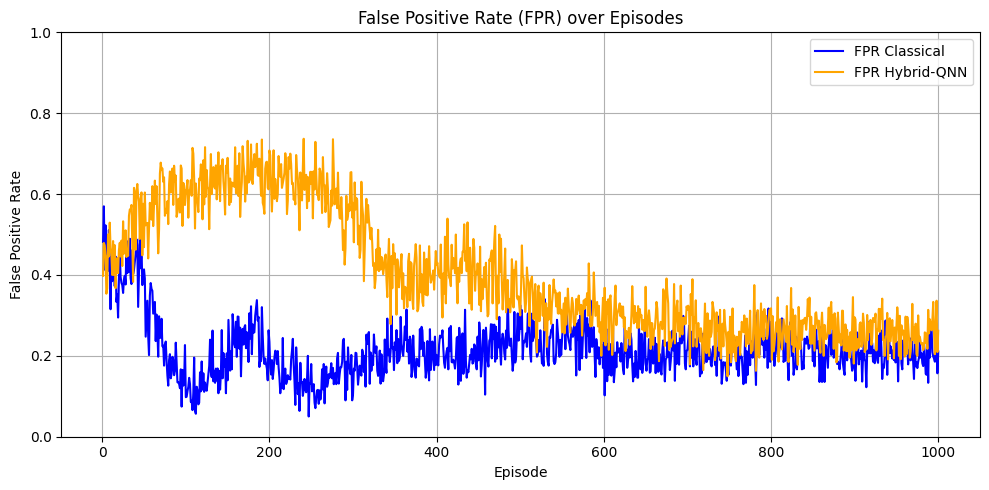

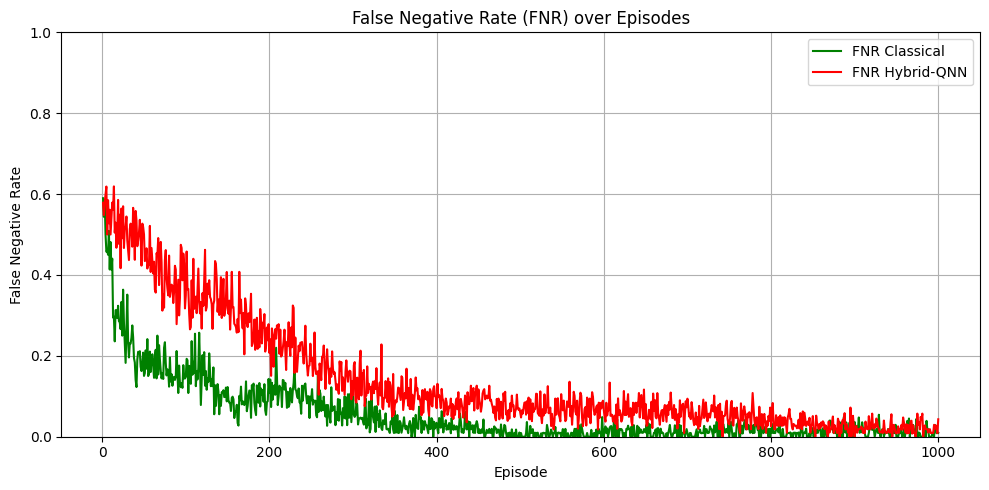

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/IQP-pca4/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# **PCA 6**

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/IQP-pca6/fpr_fnr_per_episode.csv


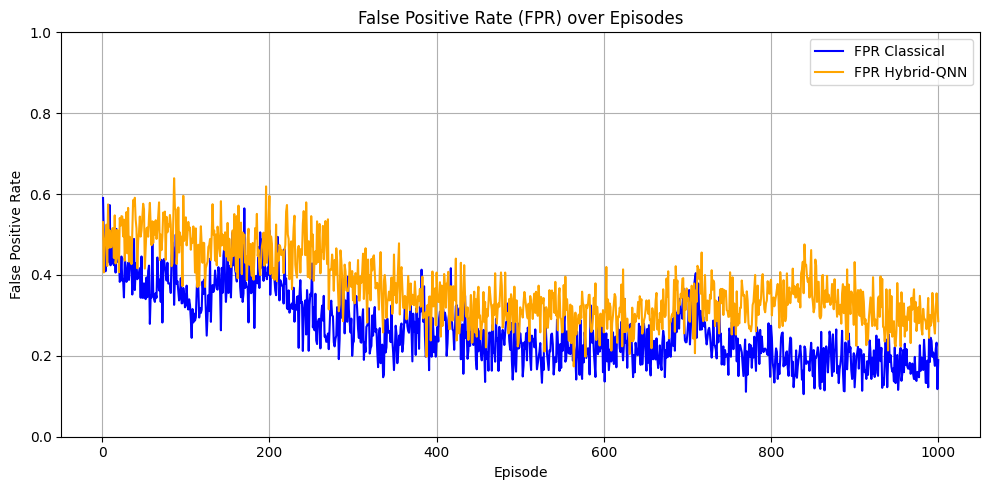

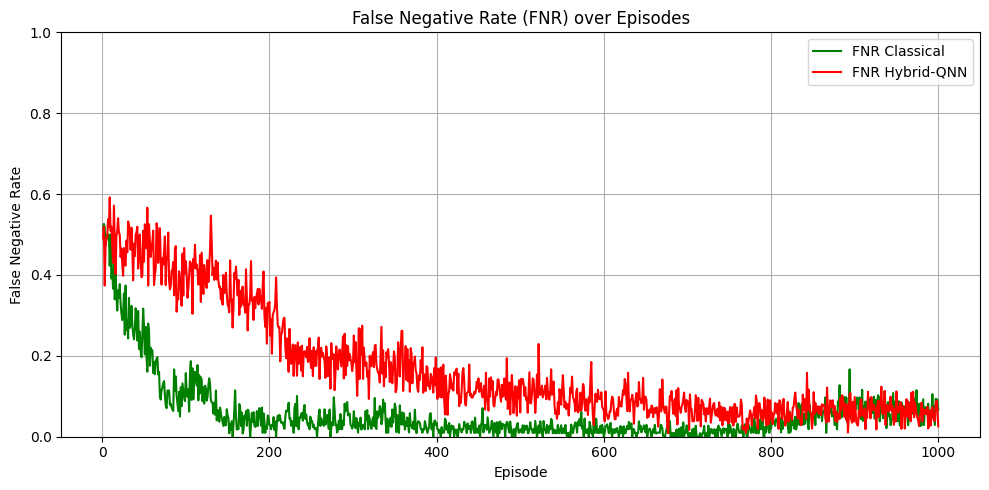

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/IQP-pca6/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")


# **PCA 8**

Loaded 1000 classical episodes and 1000 hybrid episodes.
✅ Saved FPR/FNR per episode to: /content/drive/MyDrive/phd3/outputs/IQP-pca8/fpr_fnr_per_episode.csv


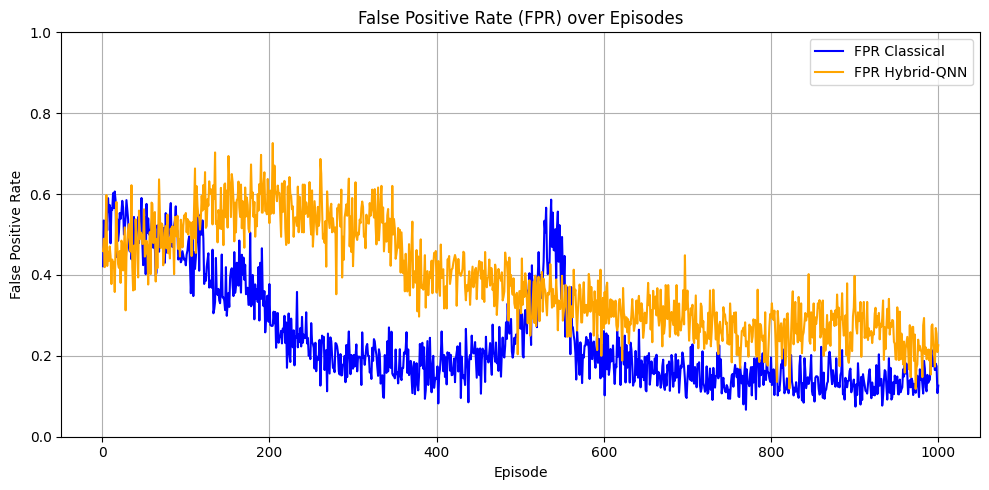

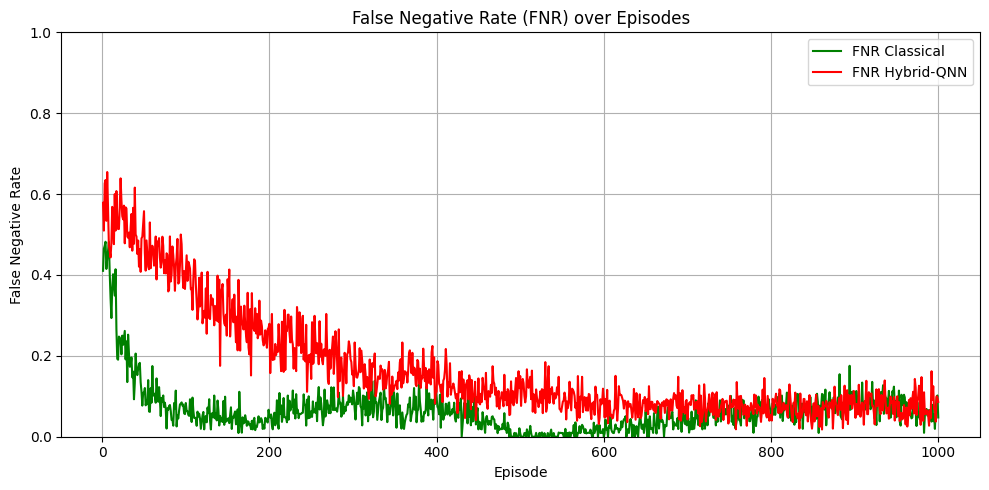

✅ FPR/FNR curves plotted and saved to output directory.


In [ ]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# 1️⃣ Load the results file
# =====================
OUTPUT_DIR = "/content/drive/MyDrive/phd3/outputs/IQP-pca8/"
with open(os.path.join(OUTPUT_DIR, "qrl_ids_results.pkl"), "rb") as f:
    results = pickle.load(f)

metrics_classical = results.get("metrics_classical", [])
metrics_hybrid = results.get("metrics_hybrid", [])

print(f"Loaded {len(metrics_classical)} classical episodes and {len(metrics_hybrid)} hybrid episodes.")

# =====================
# 2️⃣ Compute FPR & FNR for each episode
# =====================
def compute_fpr_fnr(metrics):
    fpr_list, fnr_list = [], []
    for i, m in enumerate(metrics):
        #print(f"Processing episode {i+1}/{len(metrics)}")
        #print("i:", i,"m:",m)
        cm = m.get("confusion_matrix")
        if cm is None or len(cm) != 2:
            fpr_list.append(None)
            fnr_list.append(None)
            continue
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        fpr_list.append(fpr)
        fnr_list.append(fnr)
        # Optionally, update the dictionary
        #m["false_positive_rate"] = fpr
        #m["false_negative_rate"] = fnr
    return fpr_list, fnr_list

fpr_classical, fnr_classical = compute_fpr_fnr(metrics_classical)
fpr_hybrid, fnr_hybrid = compute_fpr_fnr(metrics_hybrid)

# =====================
# 3️⃣ Save to CSV
# =====================
df = pd.DataFrame({
    "Episode": range(1, len(fpr_classical) + 1),
    "FPR_Classical": fpr_classical,
    "FNR_Classical": fnr_classical,
    "FPR_Hybrid": fpr_hybrid[:len(fpr_classical)] if metrics_hybrid else None,
    "FNR_Hybrid": fnr_hybrid[:len(fnr_classical)] if metrics_hybrid else None
})

csv_path = os.path.join(OUTPUT_DIR, "fpr_fnr_per_episode.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Saved FPR/FNR per episode to: {csv_path}")

# =====================
# 4️⃣ Plot FPR & FNR curves
# =====================
plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FPR_Classical"], label="FPR Classical", color="blue")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FPR_Hybrid"], label="FPR Hybrid-QNN", color="orange")
plt.title("False Positive Rate (FPR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fpr_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(df["Episode"], df["FNR_Classical"], label="FNR Classical", color="green")
if metrics_hybrid:
    plt.plot(df["Episode"], df["FNR_Hybrid"], label="FNR Hybrid-QNN", color="red")
plt.title("False Negative Rate (FNR) over Episodes")
plt.xlabel("Episode")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fnr_curve.png"))
plt.show()

print("✅ FPR/FNR curves plotted and saved to output directory.")
